In [1094]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

In [ ]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('val_rmse', 'mean'),
                  avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['target_instances', 'd', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['target_instances', 'd'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['target_instances', 'd', 'method', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, topk_df




In [1096]:
# For gaussian errors, we simply combine previous results with LAD results
data_gaussian = pd.read_csv('results/200_gaussian.csv')
data_gaussian = pd.read_csv('results/gaussian.csv')
data_gaussian = data_gaussian[data_gaussian['seed'] == 85]

# For slash errors
data_slash = pd.read_csv('results/200_slash.csv')
data_slash = pd.read_csv('results/slash.csv')
data_slash = data_slash[data_slash['seed'] == 85]
# data_slash = data_slash[(data_slash['seed'] != 79)
#                           & (data_slash['seed'] != 78)
#                           & (data_slash['seed'] != 77)]
#                          & (data_slash['d'] != 7)
#                          & (data_slash['d'] != 6)]

#data_slash = data_slash[data_slash['seed'] != 52]
# For slash errors
data_t= pd.read_csv('results/200_t.csv')
data_t= pd.read_csv('results/t.csv')
data_t = data_t[data_t['seed'] == 85]
# data_t = data_t[(data_t['seed'] != 79)]
#                 (data_t['d'] != 9)]

# data_t = data_t[data_t['seed'] != 52]

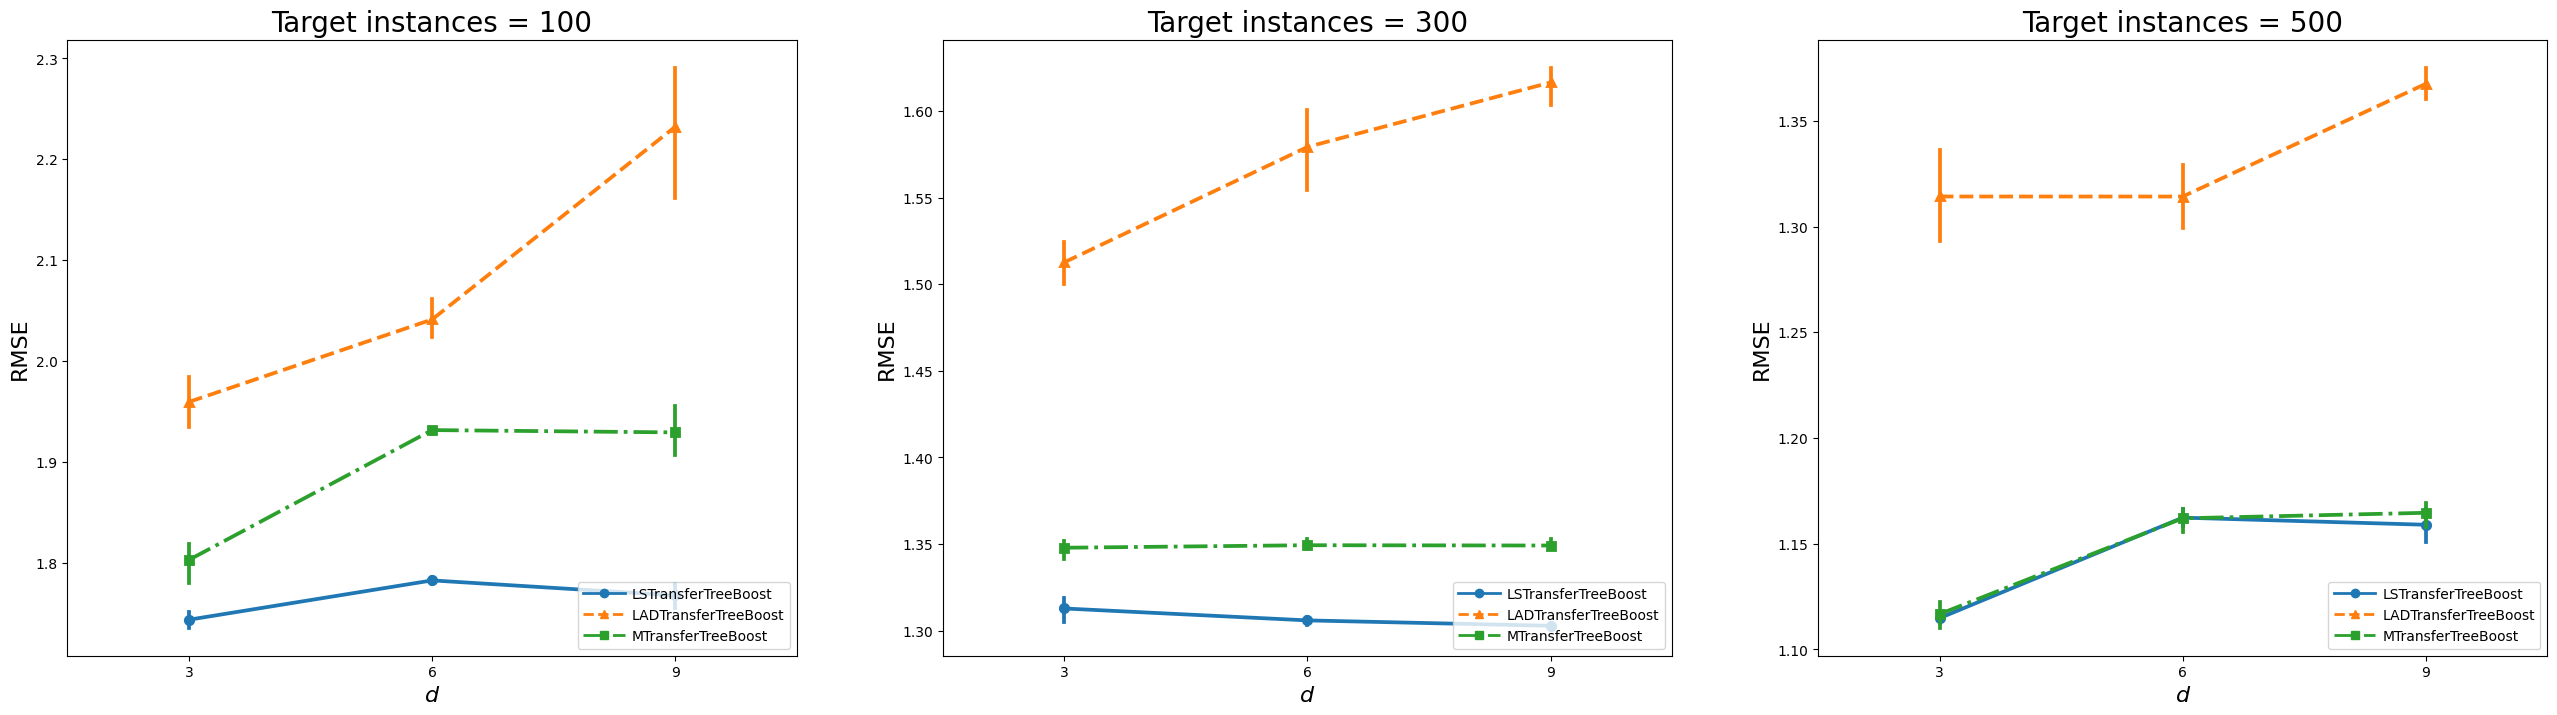

In [1097]:

# Plot average test RMSE:s for best hyperparams
from matplotlib.lines import Line2D

# Here we find the optimal settings
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['target_instances', 'd','v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

plt.figure(figsize = (32,8))

i = 1
for target_instances in data_gaussian['target_instances'].unique():
    #create new df:s for viz
    df = pd.concat([best_LS[best_LS['target_instances'] == target_instances], best_LAD[best_LAD['target_instances'] == target_instances]])
    df = pd.concat([df, best_Huber[best_Huber['target_instances'] == target_instances]])
    plt.subplot(1,3,i)
    i += 1
    sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.title(f'Target instances = {target_instances}', fontsize = 20)
plt.show()
    




<Axes: xlabel='d', ylabel='rmse'>

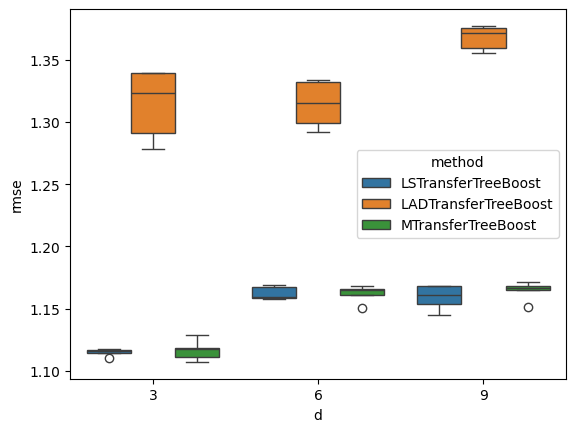

In [1098]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

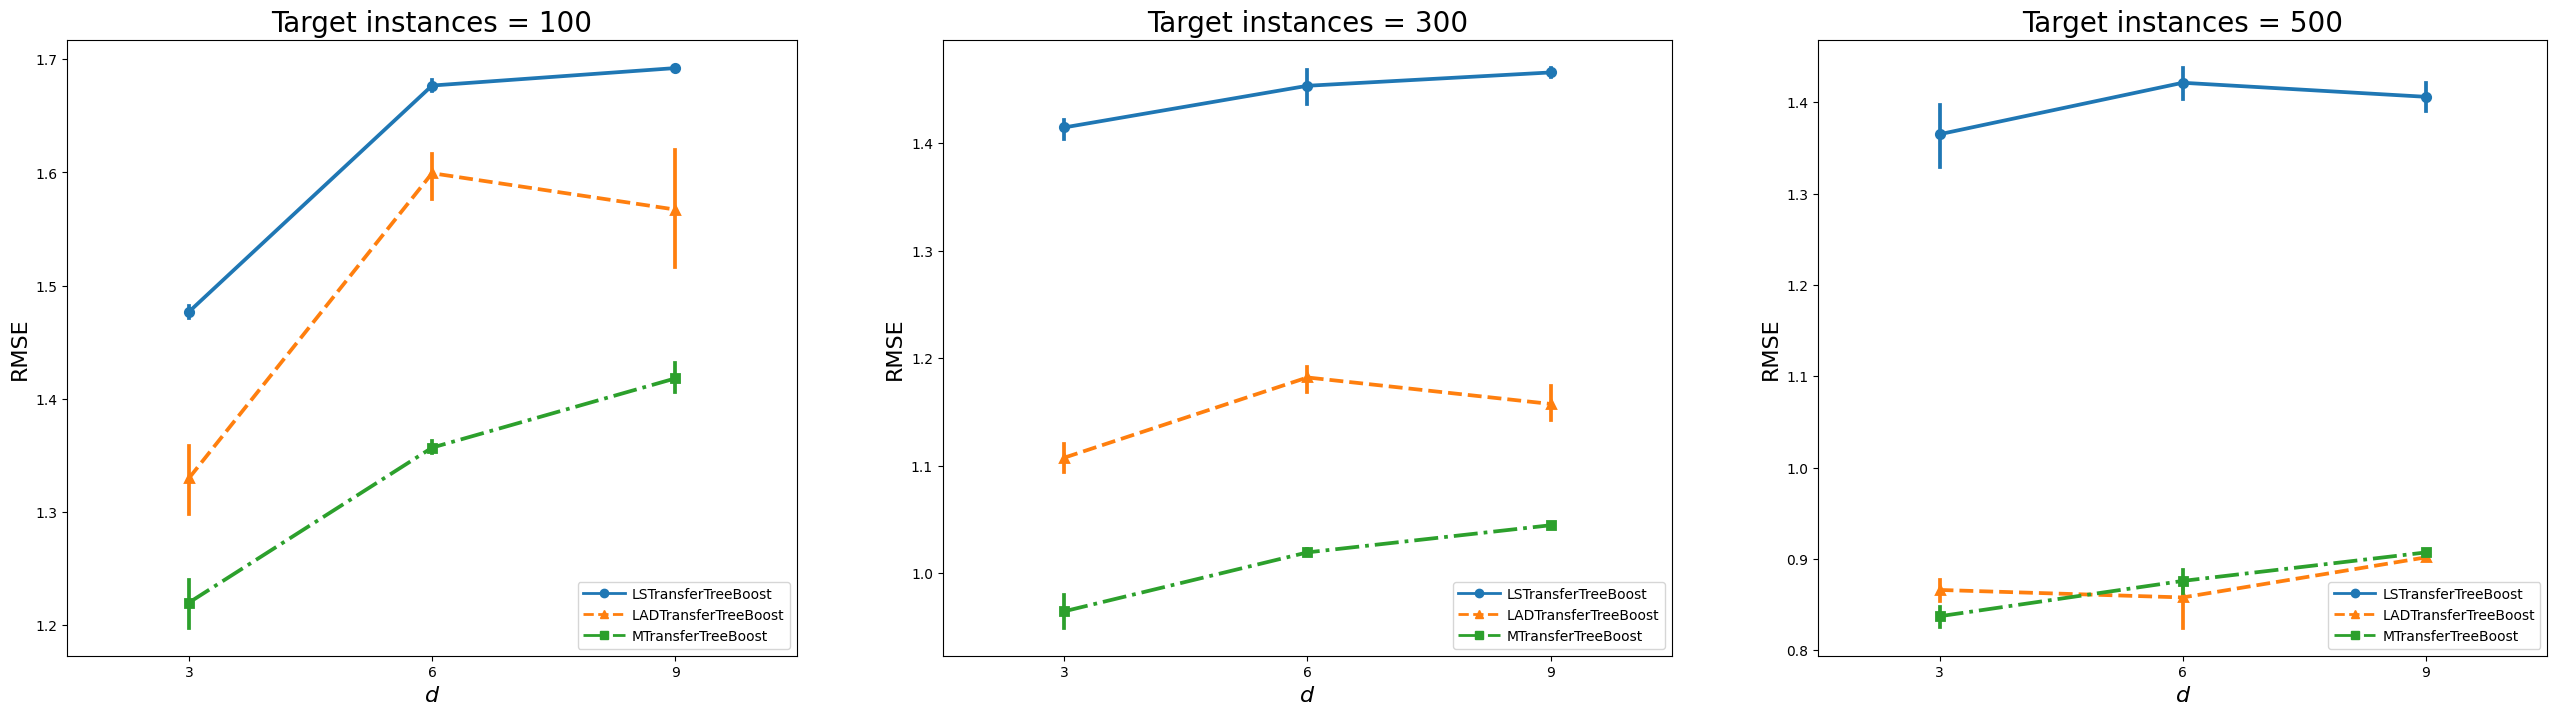

In [1099]:
# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

plt.figure(figsize = (32,8))

i = 1
for target_instances in data_gaussian['target_instances'].unique():
    #create new df:s for viz
    df = pd.concat([best_LS[best_LS['target_instances'] == target_instances], best_LAD[best_LAD['target_instances'] == target_instances]])
    df = pd.concat([df, best_Huber[best_Huber['target_instances'] == target_instances]])
    plt.subplot(1,3,i)
    i += 1
    sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.title(f'Target instances = {target_instances}', fontsize = 20)
plt.show()



<Axes: xlabel='d', ylabel='rmse'>

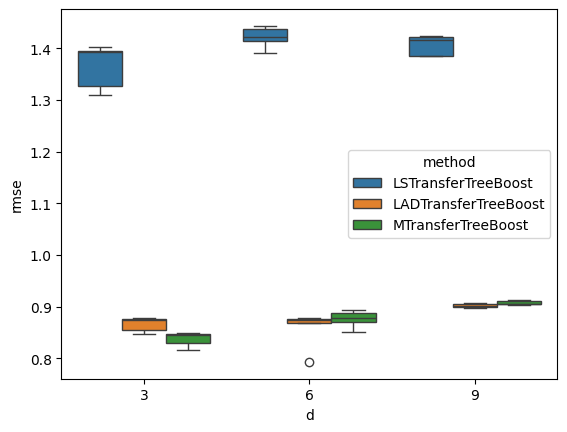

In [1100]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

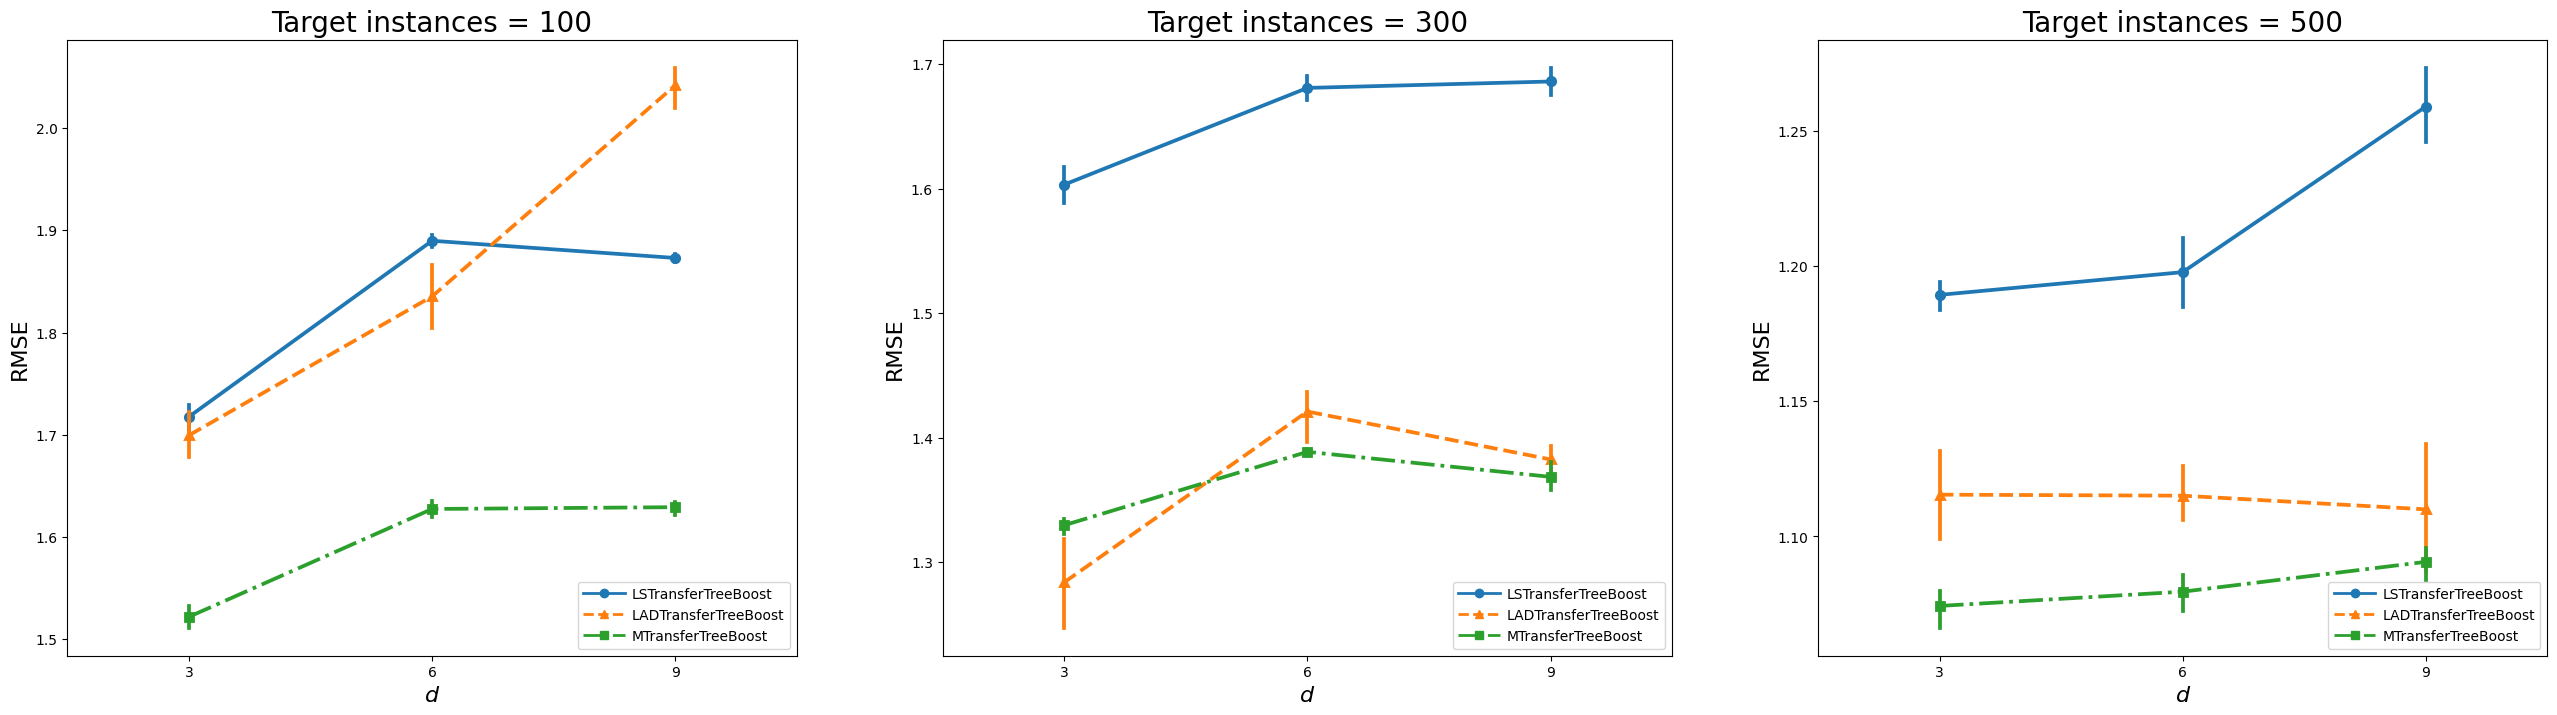

In [1101]:
# Here we find the optimal settings
LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_t,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_t,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_t,
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

plt.figure(figsize = (32,8))

i = 1
for target_instances in data_gaussian['target_instances'].unique():
    #create new df:s for viz
    df = pd.concat([best_LS[best_LS['target_instances'] == target_instances], best_LAD[best_LAD['target_instances'] == target_instances]])
    df = pd.concat([df, best_Huber[best_Huber['target_instances'] == target_instances]])
    plt.subplot(1,3,i)
    i += 1
    sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.title(f'Target instances = {target_instances}', fontsize = 20)
plt.show()

<Axes: xlabel='d', ylabel='rmse'>

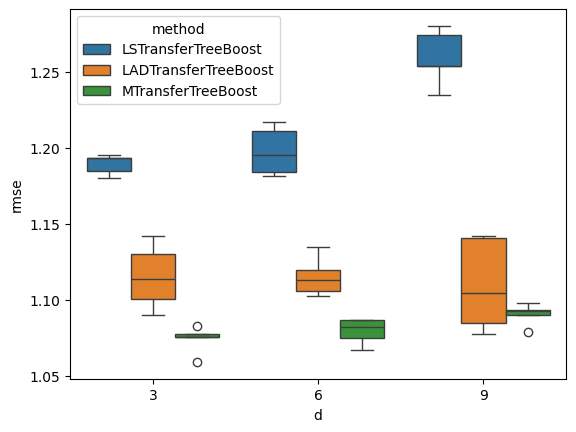

In [1102]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [1103]:
# # Here we compare different quantiles for Huber loss
# Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost'] #read previous result
# Huber_data_gaussian_25 = pd.read_csv('results/200_gaussian_025.csv')
# Huber_data_gaussian_25['method'] = 'M_25'

# Huber_data_gaussian_75 = pd.read_csv('results/200_gaussian_075.csv')
# Huber_data_gaussian_75['method'] = 'M_75'

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_gaussian,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
#     Huber_data_gaussian_25,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
#     Huber_data_gaussian_75,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# #create new df for viz
# df = pd.concat([best_Huber, best_Huber_25])
# df = pd.concat([df, best_Huber_75])

# sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

# #Then repeat in two new cells for Slash, t(2)



In [1104]:
# # Here we compare different quantiles for Huber loss
# Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost'] #read previous result
# Huber_data_slash_25 = pd.read_csv('results/200_slash_025.csv')
# Huber_data_slash_25['method'] = 'M_25'

# Huber_data_slash_75 = pd.read_csv('results/200_slash_075.csv')
# Huber_data_slash_75['method'] = 'M_75'

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_slash,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
#     Huber_data_slash_25,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
#     Huber_data_slash_75,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=1
# )

# #create new df for viz
# df = pd.concat([best_Huber, best_Huber_25])
# df = pd.concat([df, best_Huber_75])

# sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [1105]:
# # Here we compare different quantiles for Huber loss
# Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost'] #read previous result
# Huber_data_t_25 = pd.read_csv('results/200_t_025.csv')
# Huber_data_t_25['method'] = 'M_25'

# Huber_data_t_75 = pd.read_csv('results/200_t_075.csv')
# Huber_data_t_75['method'] = 'M_75'

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_t,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
# )

# best_Huber_25, best_Huber_params_25 = topk_per_d_per_method(
#     Huber_data_t_25,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
# )

# best_Huber_75, best_Huber_params_75 = topk_per_d_per_method(
#     Huber_data_t_75,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
# )

# #create new df for viz
# df = pd.concat([best_Huber, best_Huber_25])
# df = pd.concat([df, best_Huber_75])

# sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

# Here we make final vizes!

In [1106]:
# # For gaussian errors, we simply combine previous results with LAD results
# data_gaussian = pd.read_csv('results/200_gaussian.csv')

# # For slash errors
# data_slash = pd.read_csv('results/200_slash.csv')

# #for t(2) errors
# data_t= pd.read_csv('results/200_t.csv')



In [1107]:
# # Here we find the optimal settings
# LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
# LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
# Huber_data_gaussian = pd.read_csv('results/200_gaussian_075.csv')

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_gaussian,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_gaussian,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_gaussian,
# ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# #create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [1108]:
# # Here we find the optimal settings
# LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
# LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
# Huber_data_slash = pd.read_csv('results/200_slash_075.csv')

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# # create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# sns.boxplot(data=df, x='d', y='rmse', hue='method')


In [1109]:

# plt.figure(figsize = (14,16))
# import matplotlib as mpl
# # Here we find the optimal settings
# LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
# LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
# Huber_data_gaussian = pd.read_csv('results/200_gaussian_075.csv')
# LS_data_gaussian['method'] = 'LS'
# LAD_data_gaussian['method'] = 'LAD'
# Huber_data_gaussian['method'] = 'M'

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_gaussian,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_gaussian,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_gaussian,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# # create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# plt.subplot(3,2,1)
# ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
# plt.title('Gaussian', fontsize = 14)
# plt.ylabel('RMSE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')

# plt.subplot(3,2,2)
# ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
# plt.title('Gaussian', fontsize = 14)
# plt.ylabel('MAE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')


# # Here we find the optimal settings
# LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
# LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
# Huber_data_slash = pd.read_csv('results/200_slash_075.csv')
# LS_data_slash['method'] = 'LS'
# LAD_data_slash['method'] = 'LAD'
# Huber_data_slash['method'] = 'M'

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_slash,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# # create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# plt.subplot(3,2,3)
# ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
# plt.title('Slash', fontsize = 14)
# plt.ylabel('RMSE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')

# plt.subplot(3,2,4)
# ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
# plt.title('Slash', fontsize = 14)
# plt.ylabel('MAE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')


# # Here we find the optimal settings
# LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
# LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
# Huber_data_t = pd.read_csv('results/200_t_075.csv')
# LS_data_t['method'] = 'LS'
# LAD_data_t['method'] = 'LAD'
# Huber_data_t['method'] = 'M'

# best_LS, best_LS_params = topk_per_d_per_method(
#     LS_data_t,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_LAD, best_LAD_params = topk_per_d_per_method(
#     LAD_data_t,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# best_Huber, best_Huber_params = topk_per_d_per_method(
#     Huber_data_t,
#     ['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=30
# )

# # create new df for viz
# df = pd.concat([best_LS, best_LAD])
# df = pd.concat([df, best_Huber])
# plt.subplot(3,2,5)
# ax = sns.boxplot(x='d', y='rmse', hue='method', data=df, showfliers=False)
# plt.title('t(2)', fontsize = 14)
# plt.ylabel('RMSE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')

# plt.subplot(3,2,6)
# ax = sns.boxplot(x='d', y='mae', hue='method', data=df, showfliers=False)
# plt.title('t(2)', fontsize = 14)
# plt.ylabel('MAE', fontsize=12)
# plt.xlabel('d', fontsize=12)
# # hatches must equal the number of hues (3 in this case)
# hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
# # select the correct patches
# patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
# # the number of patches should be evenly divisible by the number of hatches
# h = hatches * (len(patches) // len(hatches))
# # iterate through the patches for each subplot
# for patch, hatch in zip(patches, h):
#     patch.set_hatch(hatch)
#     fc = patch.get_facecolor()
#     patch.set_edgecolor(fc)
#     patch.set_facecolor('none')

# l = ax.legend()
# hatches_in_plot = ['//', '..', 'xx']
# for lp, hatch in zip(l.get_patches(), hatches_in_plot):
#     lp.set_hatch(hatch)
#     fc = lp.get_facecolor()
#     lp.set_edgecolor(fc)
#     lp.set_facecolor('none')

# plt.savefig('vizes/esann_viz.png', bbox_inches = 'tight', pad_inches = 0.05, dpi = 300)


# Final viz comes here!!!!
data = pd.read_csv('results/200_gaussian_6_optim.csv')
data_slash = pd.read_csv('results/200_slash_6_optim.csv')
# We remove one very weird result. As this did not happen in any other experiment, 
# we believe this is a numerical issue with the code. We remove the seed for both methods.
data = data[data['seed'] != 18] 
data_slash = data_slash[data_slash['seed'] != 18]
data['method'] = data['method'].replace("LSTransferTreeBoost", "LS")
data['method'] = data['method'].replace("LADTransferTreeBoost", "LAD")

data_slash['method'] = data_slash['method'].replace("LSTransferTreeBoost", "LS")
data_slash['method'] = data_slash['method'].replace("LADTransferTreeBoost", "LAD")

plt.figure(figsize = (14,10))

plt.subplot(2,2,1)
sns.boxplot(data = data, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,2)
sns.boxplot(data = data, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,3)
sns.boxplot(data = data_slash, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.subplot(2,2,4)
sns.boxplot(data = data_slash, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.savefig('vizes/ls-lad.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)







In [1110]:
best_LS_params

,target_instances,d,v,source_tree_size,target_tree_size,m_0,k,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,method,epochs,val_rmse,val_mae,rmse,mae
111,100,3,0.10,2,1,0.5,0.00,1.703273,1.295418,1,327,85,LSTransferTreeBoost,400,1.639784,1.295418,1.703273,1.347680
84,100,3,0.10,1,1,0.5,0.00,1.703991,1.271812,1,246,85,LSTransferTreeBoost,400,1.625480,1.271812,1.703991,1.341779
43,100,3,0.05,2,2,0.9,0.01,1.715488,1.294886,1,123,85,LSTransferTreeBoost,400,1.633404,1.294886,1.715488,1.356763
30,100,3,0.05,2,1,0.5,0.00,1.729520,1.313078,1,84,85,LSTransferTreeBoost,400,1.672158,1.313078,1.729520,1.363776
115,100,3,0.10,2,1,0.9,0.01,1.736024,1.305831,1,339,85,LSTransferTreeBoost,400,1.658291,1.305831,1.736024,1.375720
304,100,6,0.10,3,1,0.9,0.01,1.882625,1.391028,1,1878,85,LSTransferTreeBoost,400,1.783167,1.391028,1.882625,1.467945
283,100,6,0.10,2,2,0.5,0.01,1.883440,1.403075,1,1821,85,LSTransferTreeBoost,400,1.782173,1.403075,1.883440,1.487258
301,100,6,0.10,3,1,0.5,0.01,1.886674,1.397994,1,1875,85,LSTransferTreeBoost,400,1.784030,1.397994,1.886674,1.477007
297,100,6,0.10,3,1,0.1,0.00,1.897073,1.393093,1,1863,85,LSTransferTreeBoost,400,1.767454,1.393093,1.897073,1.493114
217,100,6,0.05,3,1,0.1,0.01,1.898763,1.385323,1,1629,85,LSTransferTreeBoost,400,1.753382,1.385323,1.898763,1.496889
